# 04 · Model training, evaluation and explanation

Training itself is scripted in `model/train.py` (run `python -m model.train`, ~5 min). This notebook loads its
outputs (`data/processed/metrics.json`, `model/*.pkl`) and walks through the results:

* Random Forest vs XGBoost, stratified split + stratified 5-fold CV + spatially-blocked 5-fold CV
* label-leakage experiment (clean / leaky / as-specified) and physical-only ablation
* per-region performance with low-sample flags
* ML vs AHP, global vs local model on Tamil Nadu
* SHAP global summaries and a per-site explanation, energy estimate

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from model import config
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

from IPython.display import Image, display
m = json.loads((config.PROCESSED_DIR / 'metrics.json').read_text())

## Model comparison

In [2]:
def table(res):
    rows = []
    for v, vd in res['variants'].items():
        for mn, r in vd['models'].items():
            t = r['test']
            rows.append({'variant': v, 'model': mn, 'accuracy': t['accuracy'], 'precision': t['precision'],
                         'recall': t['recall'], 'f1': t['f1'], 'roc_auc': t['roc_auc'],
                         'cv_auc': r['cv_stratified_auc']['mean'], 'spatial_cv_auc': r['cv_spatial_auc']['mean'],
                         'auc_on_preconstruction_land': r.get('test_on_preconstruction_land', {}).get('roc_auc')})
    a = res['ahp_test']
    rows.append({'variant': 'baseline', 'model': 'AHP', 'accuracy': a['accuracy'], 'precision': a['precision'],
                 'recall': a['recall'], 'f1': a['f1'], 'roc_auc': a['roc_auc']})
    return pd.DataFrame(rows).round(3)
print('GLOBAL  (deployed:', m['global']['deployed_model'], ')'); display(table(m['global']))
print('TAMIL NADU  (deployed:', m['tamil_nadu']['deployed_model'], ')'); display(table(m['tamil_nadu']))

GLOBAL  (deployed: XGBoost )


,variant,model,accuracy,precision,recall,f1,roc_auc,cv_auc,spatial_cv_auc,auc_on_preconstruction_land
0,clean,Random Forest,0.804,0.751,0.881,0.811,0.889,0.893,0.878,0.889
1,clean,XGBoost,0.808,0.764,0.864,0.811,0.888,0.892,0.879,0.888
2,leaky,Random Forest,0.834,0.787,0.895,0.838,0.913,0.916,0.904,0.836
3,leaky,XGBoost,0.841,0.803,0.883,0.841,0.915,0.920,0.908,0.829
4,as_specified,Random Forest,0.888,0.872,0.897,0.884,0.955,0.958,0.954,NaN
5,as_specified,XGBoost,0.897,0.882,0.904,0.893,0.958,0.961,0.956,NaN
6,physical_only,Random Forest,0.768,0.717,0.847,0.777,0.850,0.846,0.818,0.850
7,physical_only,XGBoost,0.762,0.714,0.837,0.770,0.845,0.842,0.818,0.845
8,baseline,AHP,0.611,0.559,0.873,0.682,0.622,NaN,NaN,NaN


TAMIL NADU  (deployed: Random Forest )


,variant,model,accuracy,precision,recall,f1,roc_auc,cv_auc,spatial_cv_auc,auc_on_preconstruction_land
0,clean,Random Forest,0.843,0.841,0.749,0.792,0.931,0.970,0.928,0.931
1,clean,XGBoost,0.828,0.816,0.737,0.774,0.927,0.976,0.925,0.927
2,leaky,Random Forest,0.925,0.921,0.890,0.905,0.981,0.990,0.984,0.902
3,leaky,XGBoost,0.925,0.924,0.887,0.905,0.983,0.991,0.983,0.913
4,as_specified,Random Forest,0.937,0.938,0.901,0.919,0.984,0.991,0.986,NaN
5,as_specified,XGBoost,0.926,0.924,0.890,0.906,0.986,0.992,0.986,NaN
6,physical_only,Random Forest,0.814,0.771,0.763,0.767,0.883,0.955,0.881,0.883
7,physical_only,XGBoost,0.795,0.761,0.712,0.736,0.867,0.961,0.873,0.867
8,baseline,AHP,0.524,0.457,1.000,0.627,0.799,NaN,NaN,NaN


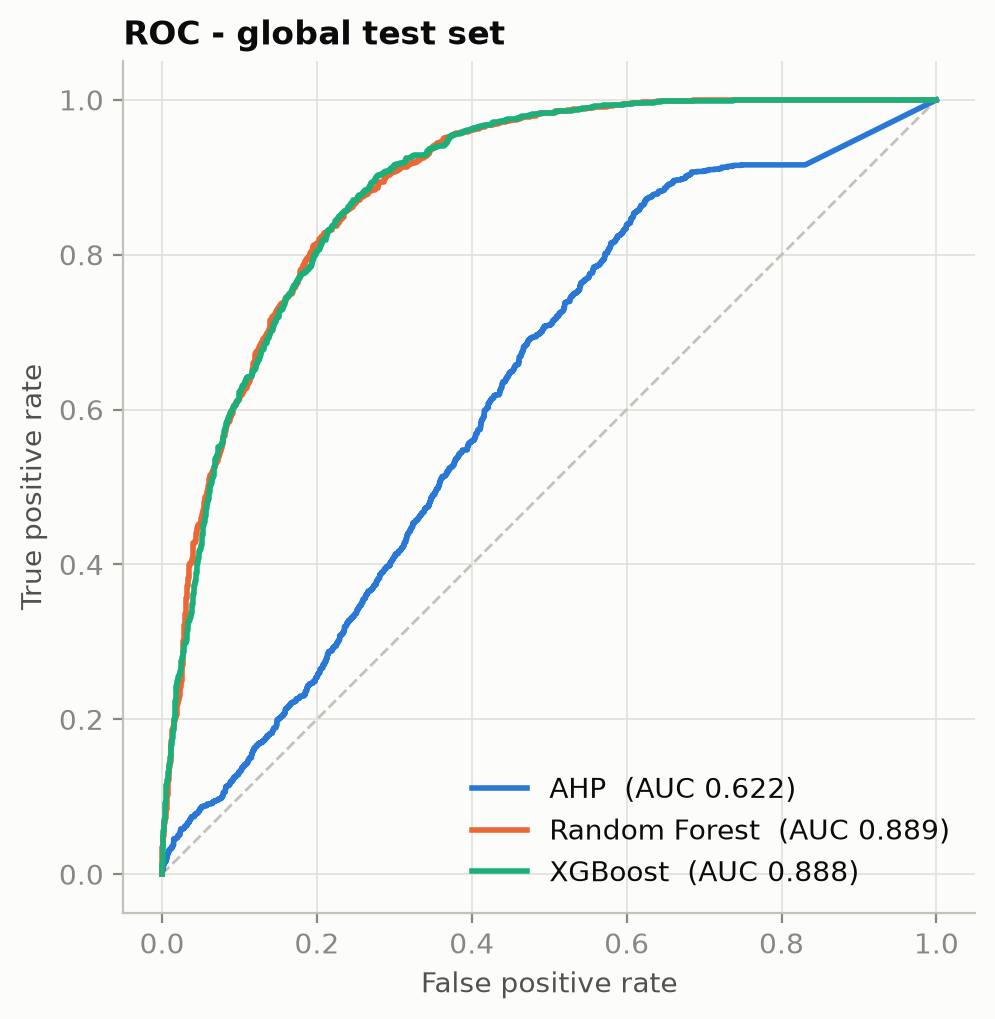

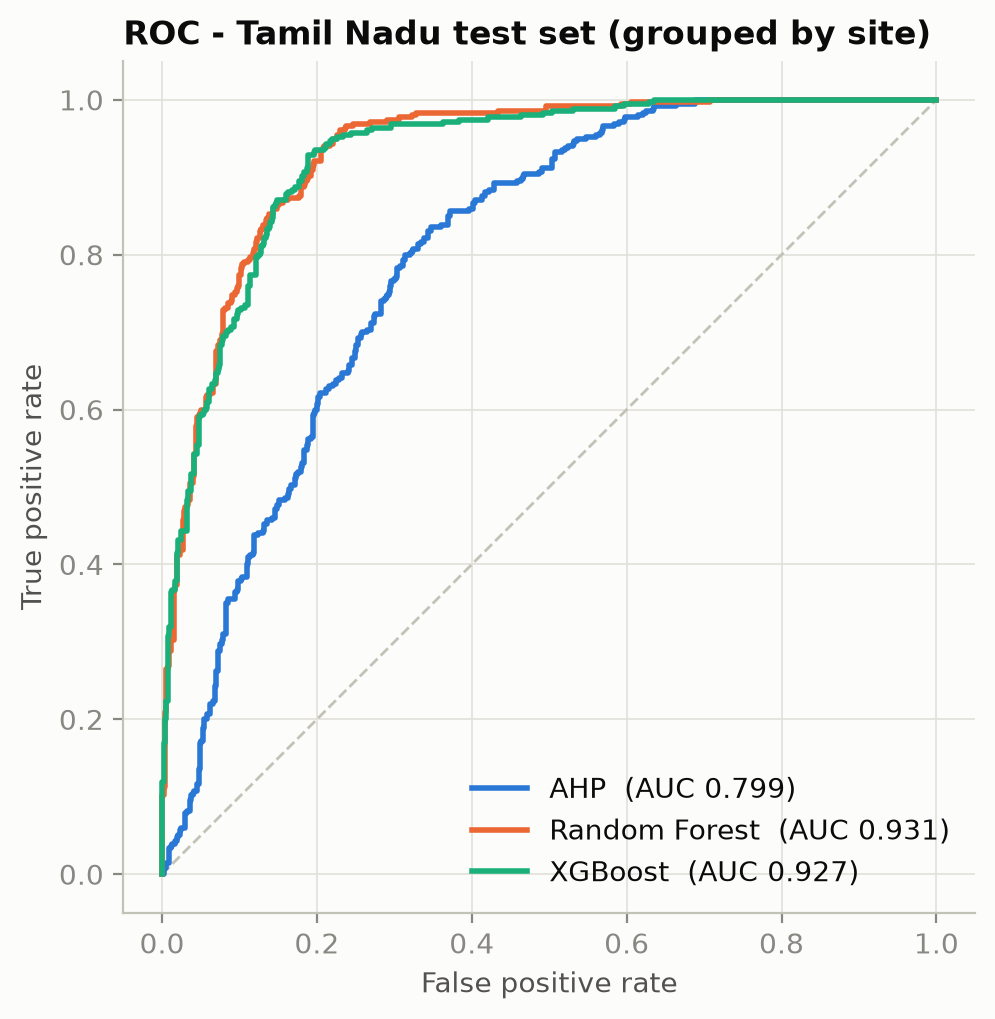

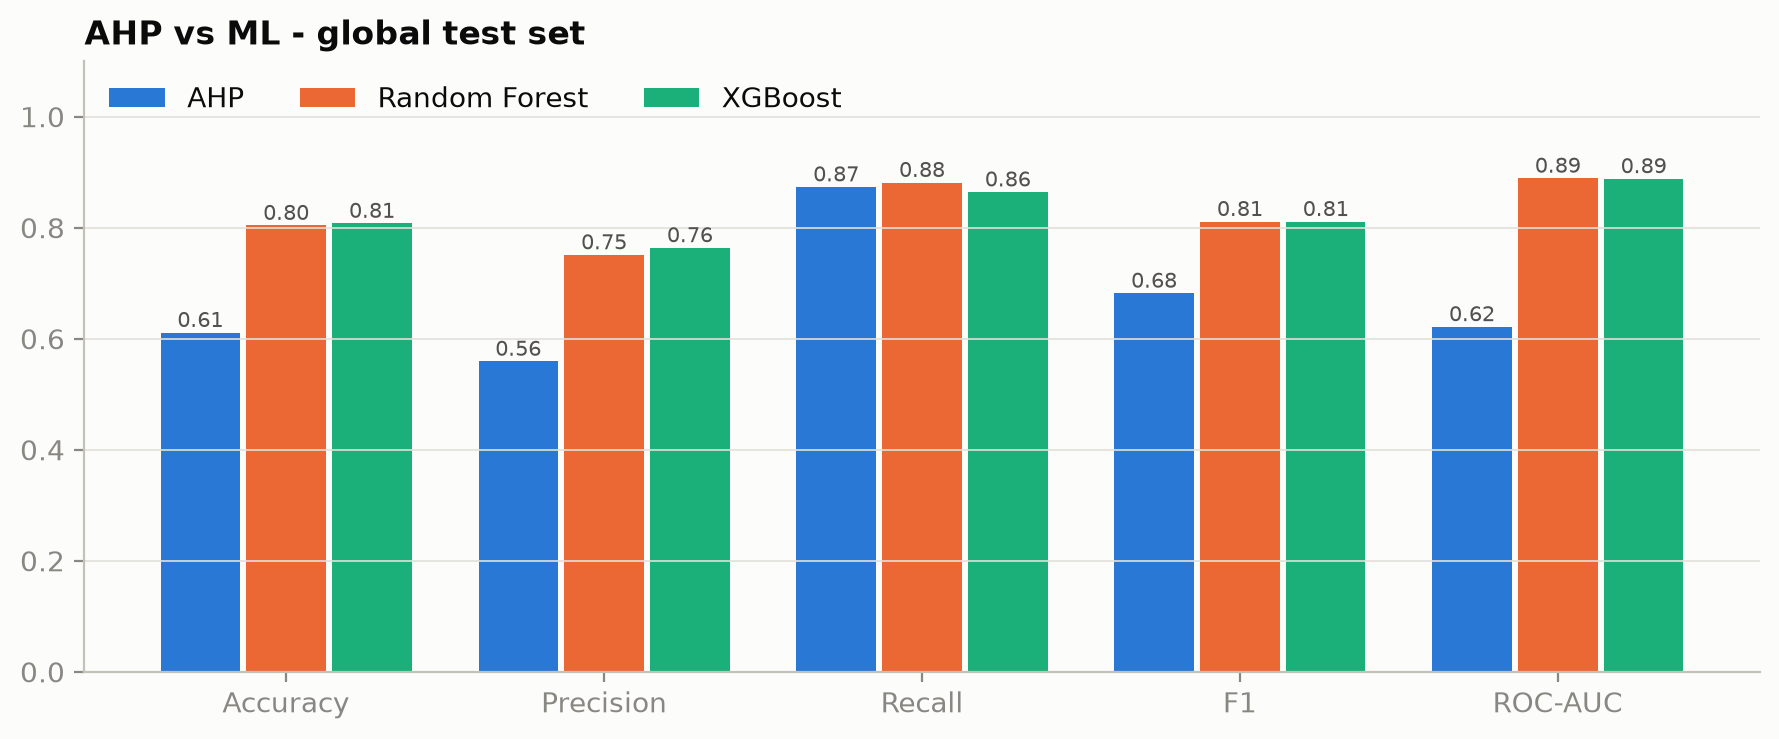

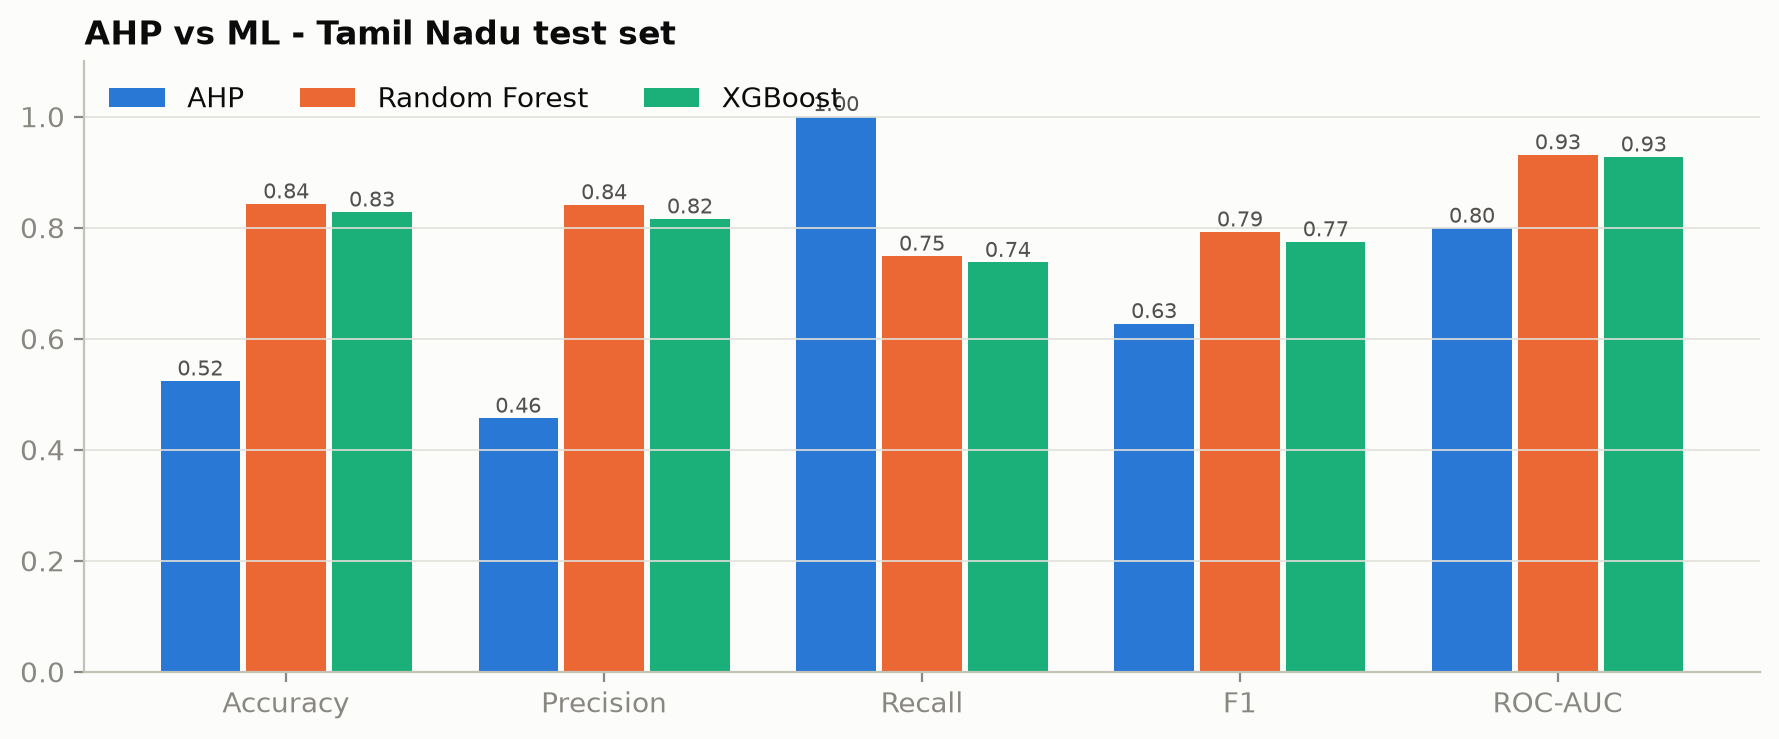

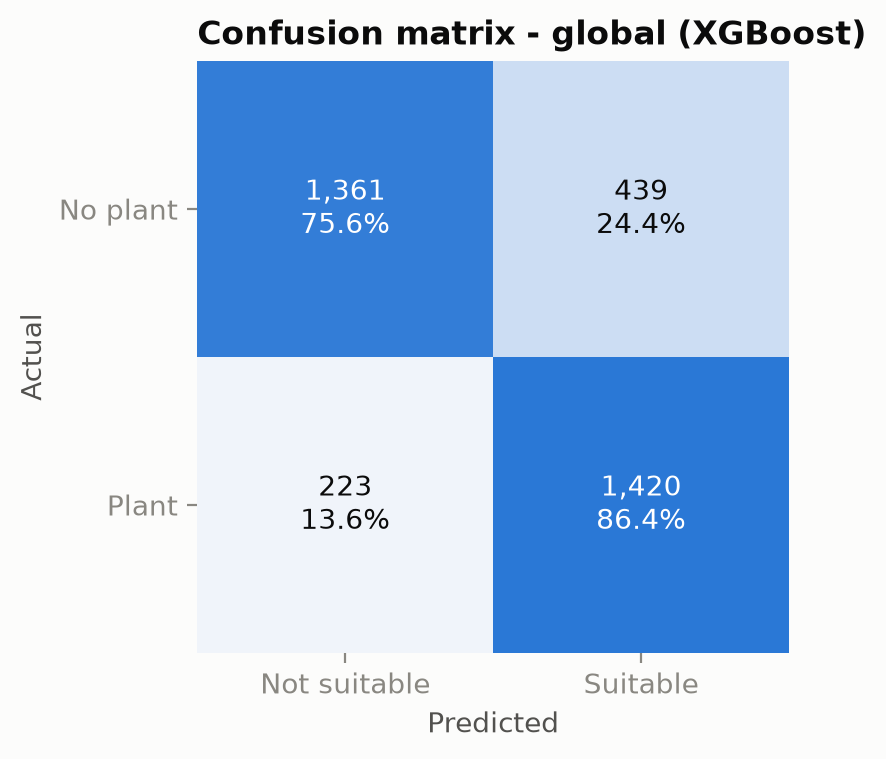

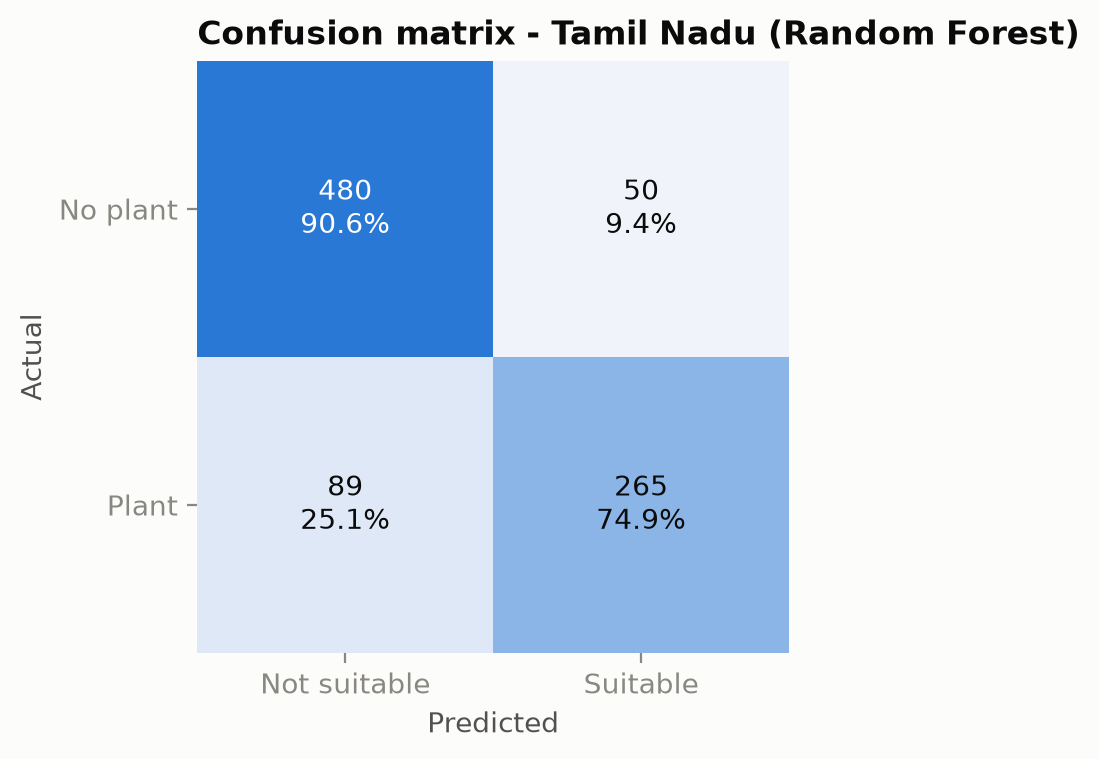

In [3]:
for f in ['roc_global.png', 'roc_tamil_nadu.png', 'ahp_vs_ml_global.png', 'ahp_vs_ml_tamil_nadu.png',
          'confusion_global.png', 'confusion_tamil_nadu.png']:
    display(Image(str(config.FIGURES_DIR / f), width=620))

## Label leakage
Models trained on *current* imagery score higher on their own test set, but that score is inflated: the imagery
shows the panels. Evaluated on **pre-construction land** - what a prospective site actually looks like - the
leaky models drop below the clean ones.

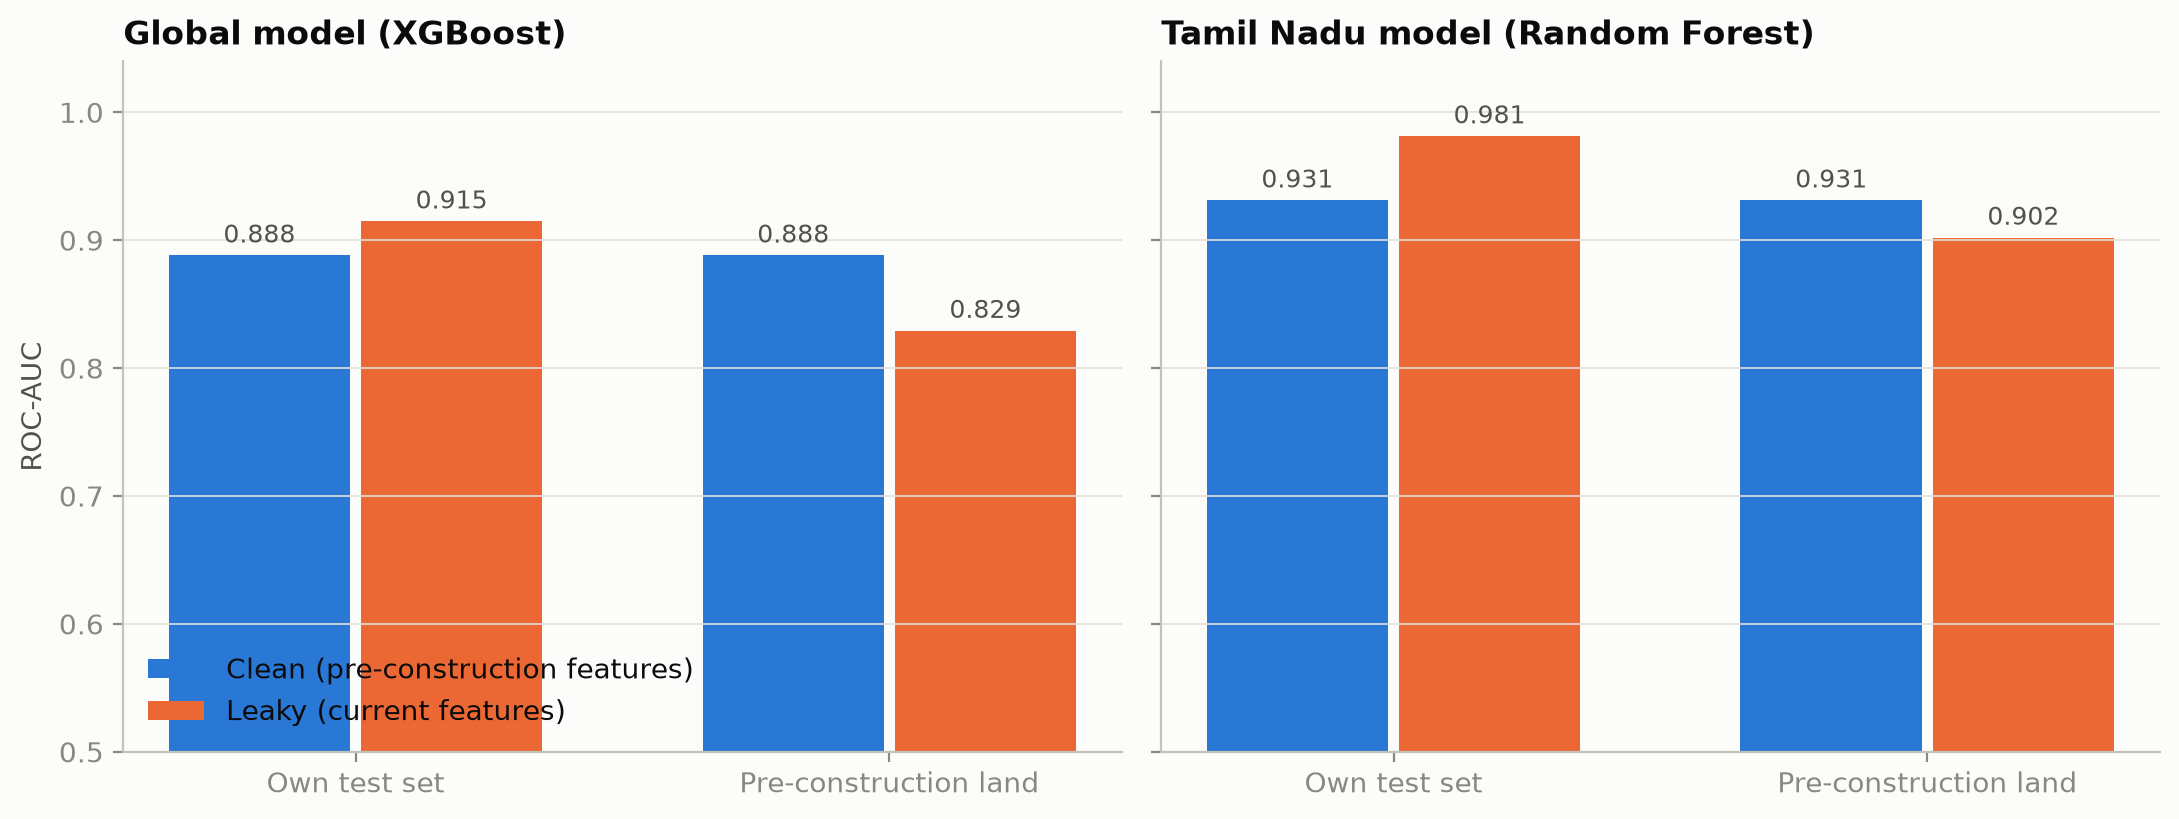

In [4]:
display(Image(str(config.FIGURES_DIR / 'leakage_experiment.png'), width=900))

## Performance by world region

,region,n,n_pos,auc,f1,precision,recall,low_sample,note
0,Africa,1445,225,0.964,0.771,0.772,0.769,False,
4,Latin America,1179,398,0.939,0.804,0.833,0.776,False,
7,Oceania,439,104,0.923,0.597,0.920,0.442,True,Only 104 labelled plants - metrics are unstabl...
1,Central & North Asia,533,16,0.922,0.581,0.600,0.562,True,Only 16 labelled plants - metrics are unstable...
3,Europe,2453,1400,0.882,0.835,0.799,0.876,False,
6,North America,2930,1400,0.874,0.787,0.756,0.821,False,
9,Southeast Asia,878,470,0.866,0.834,0.814,0.855,False,
5,Middle East,2451,1400,0.834,0.799,0.768,0.831,False,
2,East Asia,2522,1400,0.820,0.773,0.762,0.784,False,
8,South Asia,2383,1400,0.761,0.758,0.726,0.793,False,


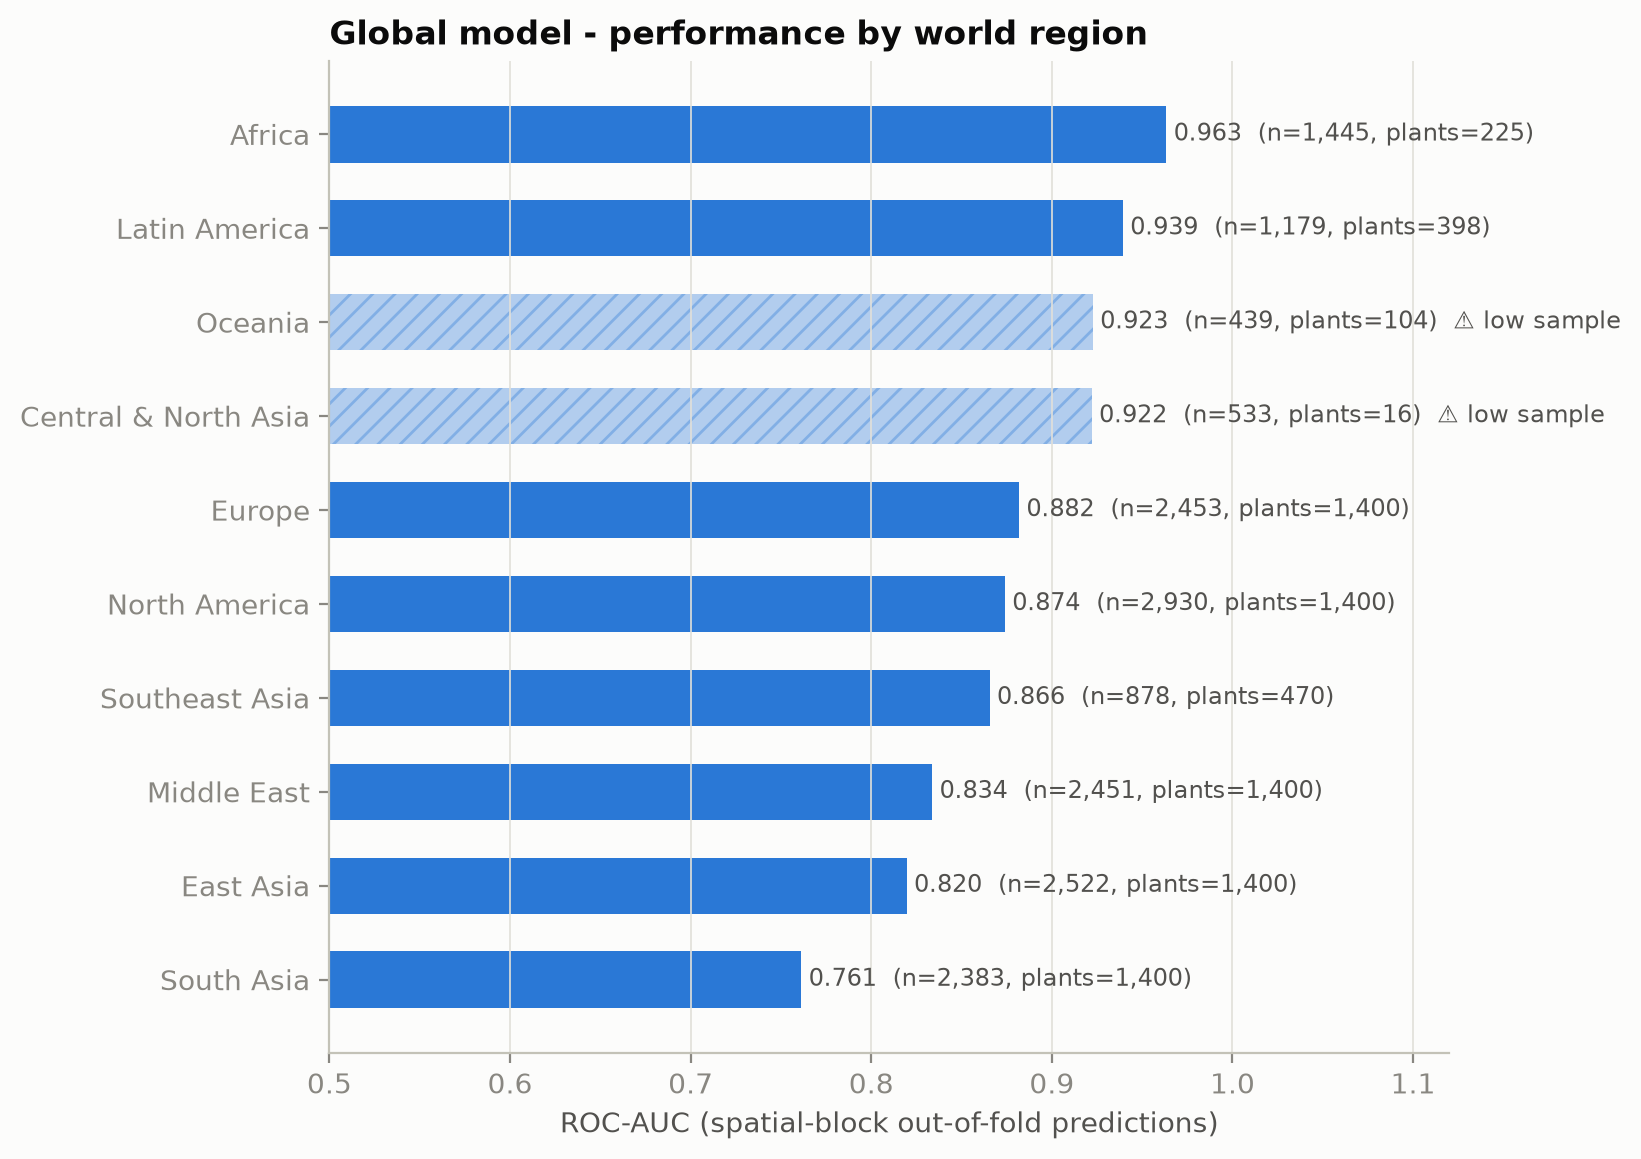

In [5]:
pr = pd.DataFrame(m['global']['per_region']).sort_values('auc', ascending=False)
display(pr[['region', 'n', 'n_pos', 'auc', 'f1', 'precision', 'recall', 'low_sample', 'note']].round(3))
display(Image(str(config.FIGURES_DIR / 'per_region_auc.png'), width=760))

## Global model vs local model on Tamil Nadu

In [6]:
gl = m['tamil_nadu']['global_vs_local']
display(pd.DataFrame({k: {x: gl[k][x] for x in ('accuracy', 'precision', 'recall', 'f1', 'roc_auc')}
                      for k in ('local', 'global', 'ahp')}).T.round(3))
print(gl['note'])

,accuracy,precision,recall,f1,roc_auc
local,0.843,0.841,0.749,0.792,0.931
global,0.712,0.583,0.980,0.731,0.860
ahp,0.524,0.457,1.000,0.627,0.799


Evaluated on the Tamil Nadu site-grouped test split. The global model is trained on the Kruitwagen inventory (independent labels, 2008-10 baseline, MODIS 500 m), the local model on OSM Tamil Nadu plants (2013-15 Landsat baseline, 30 m + OSM grid distances).


## Explainability

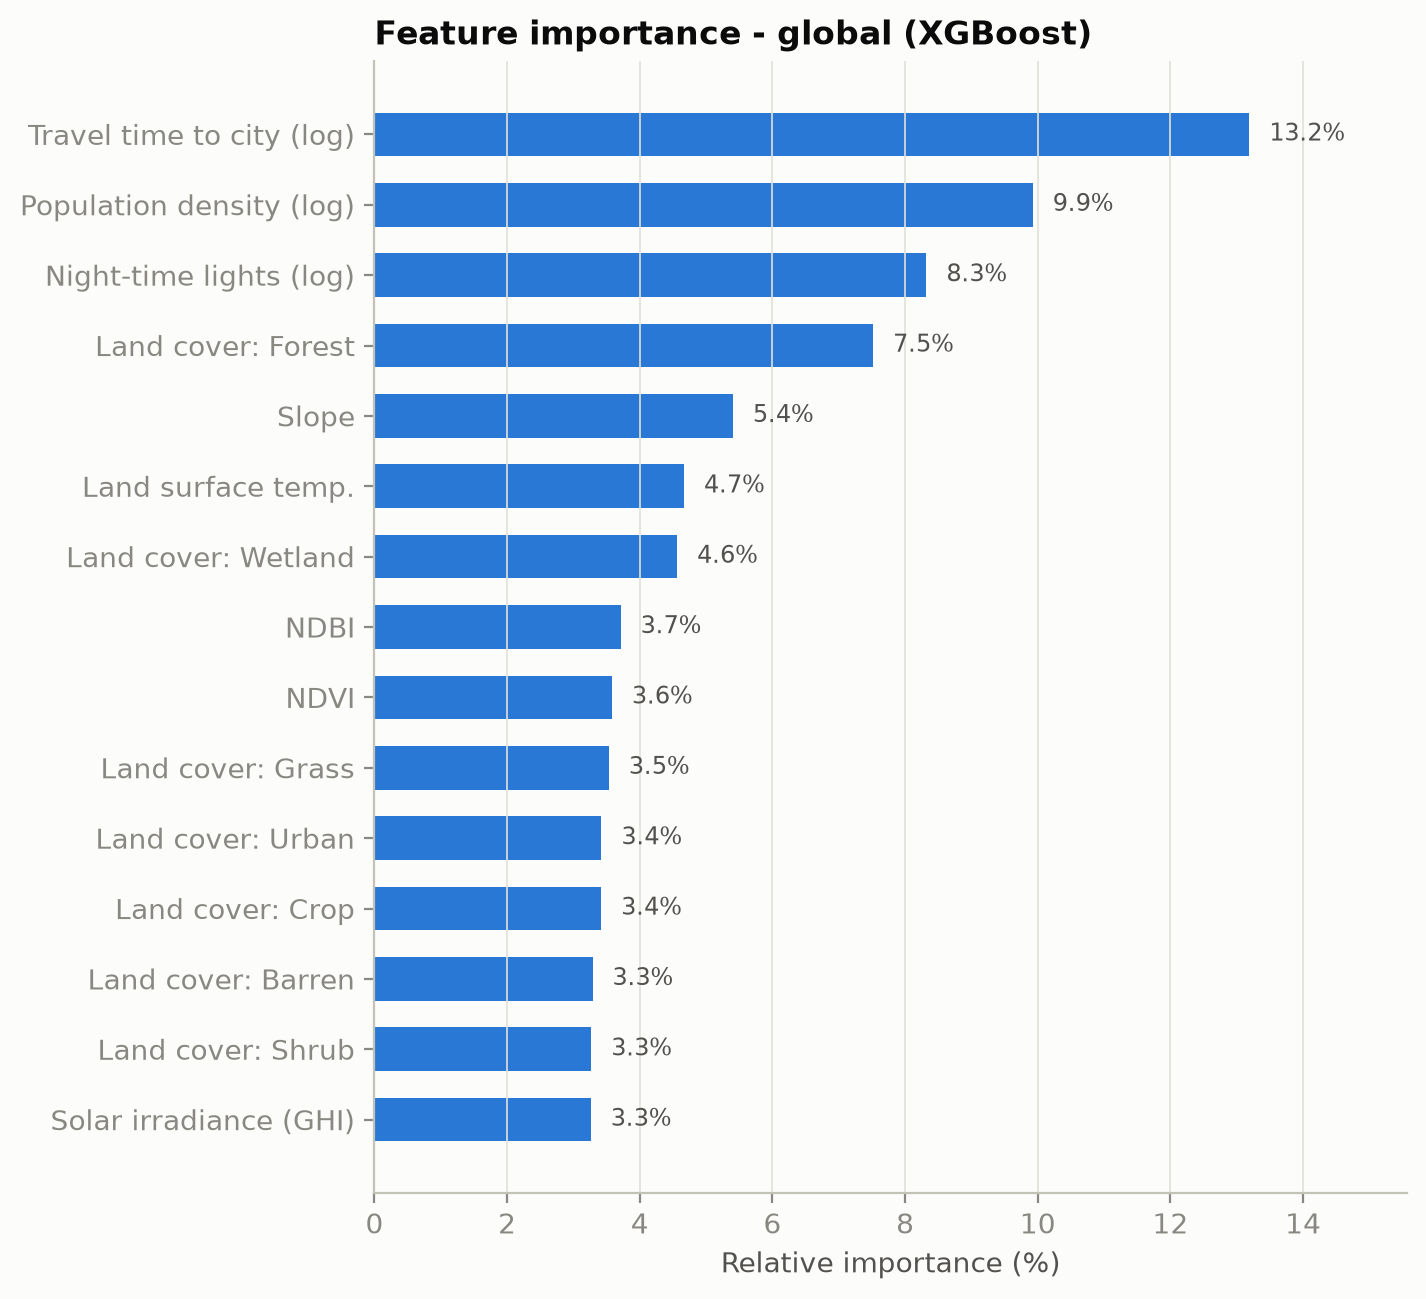

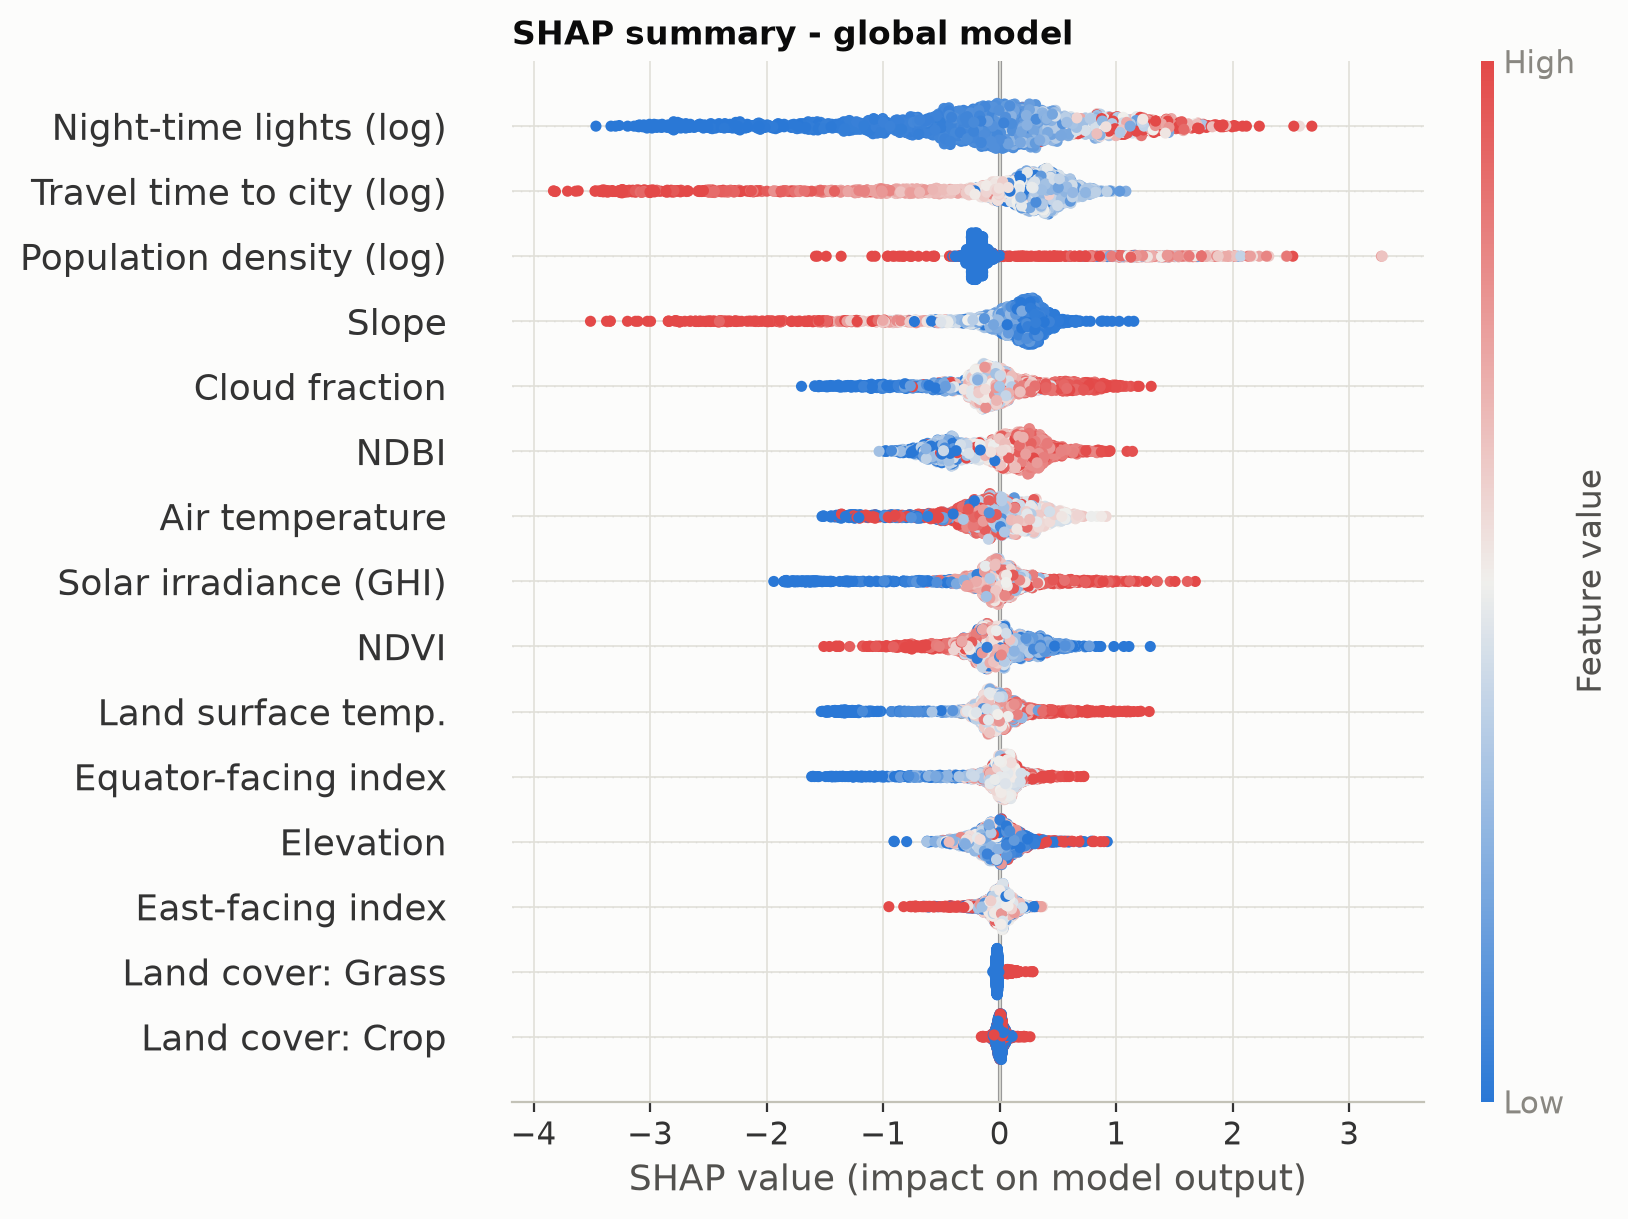

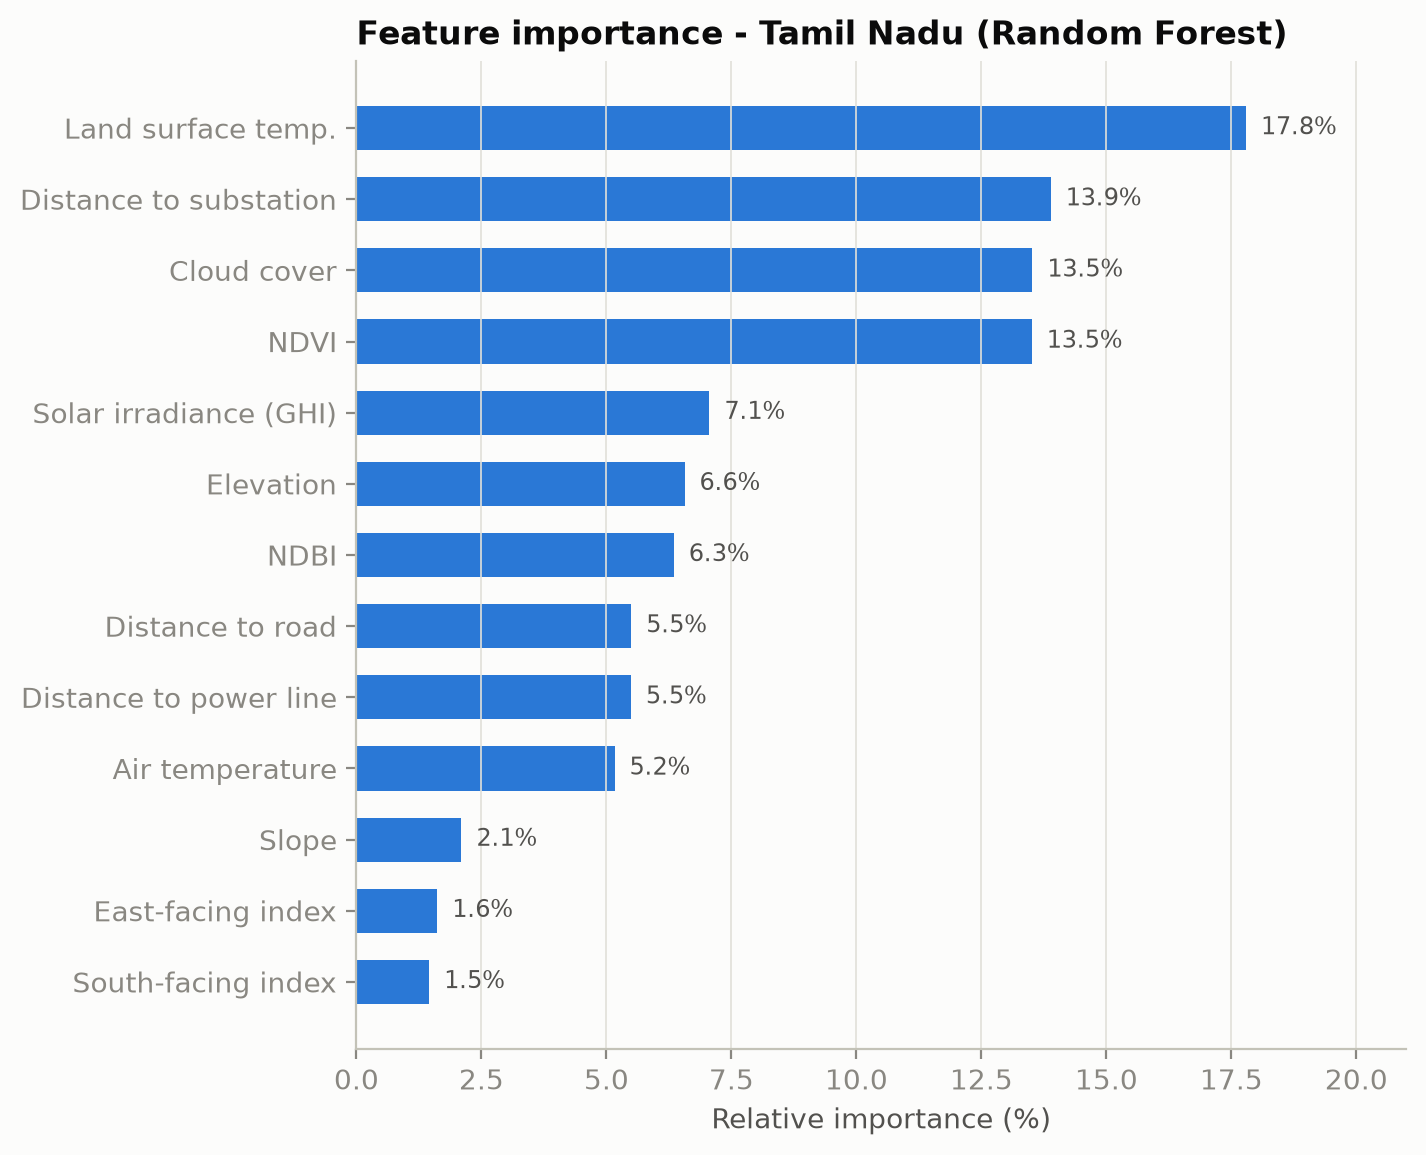

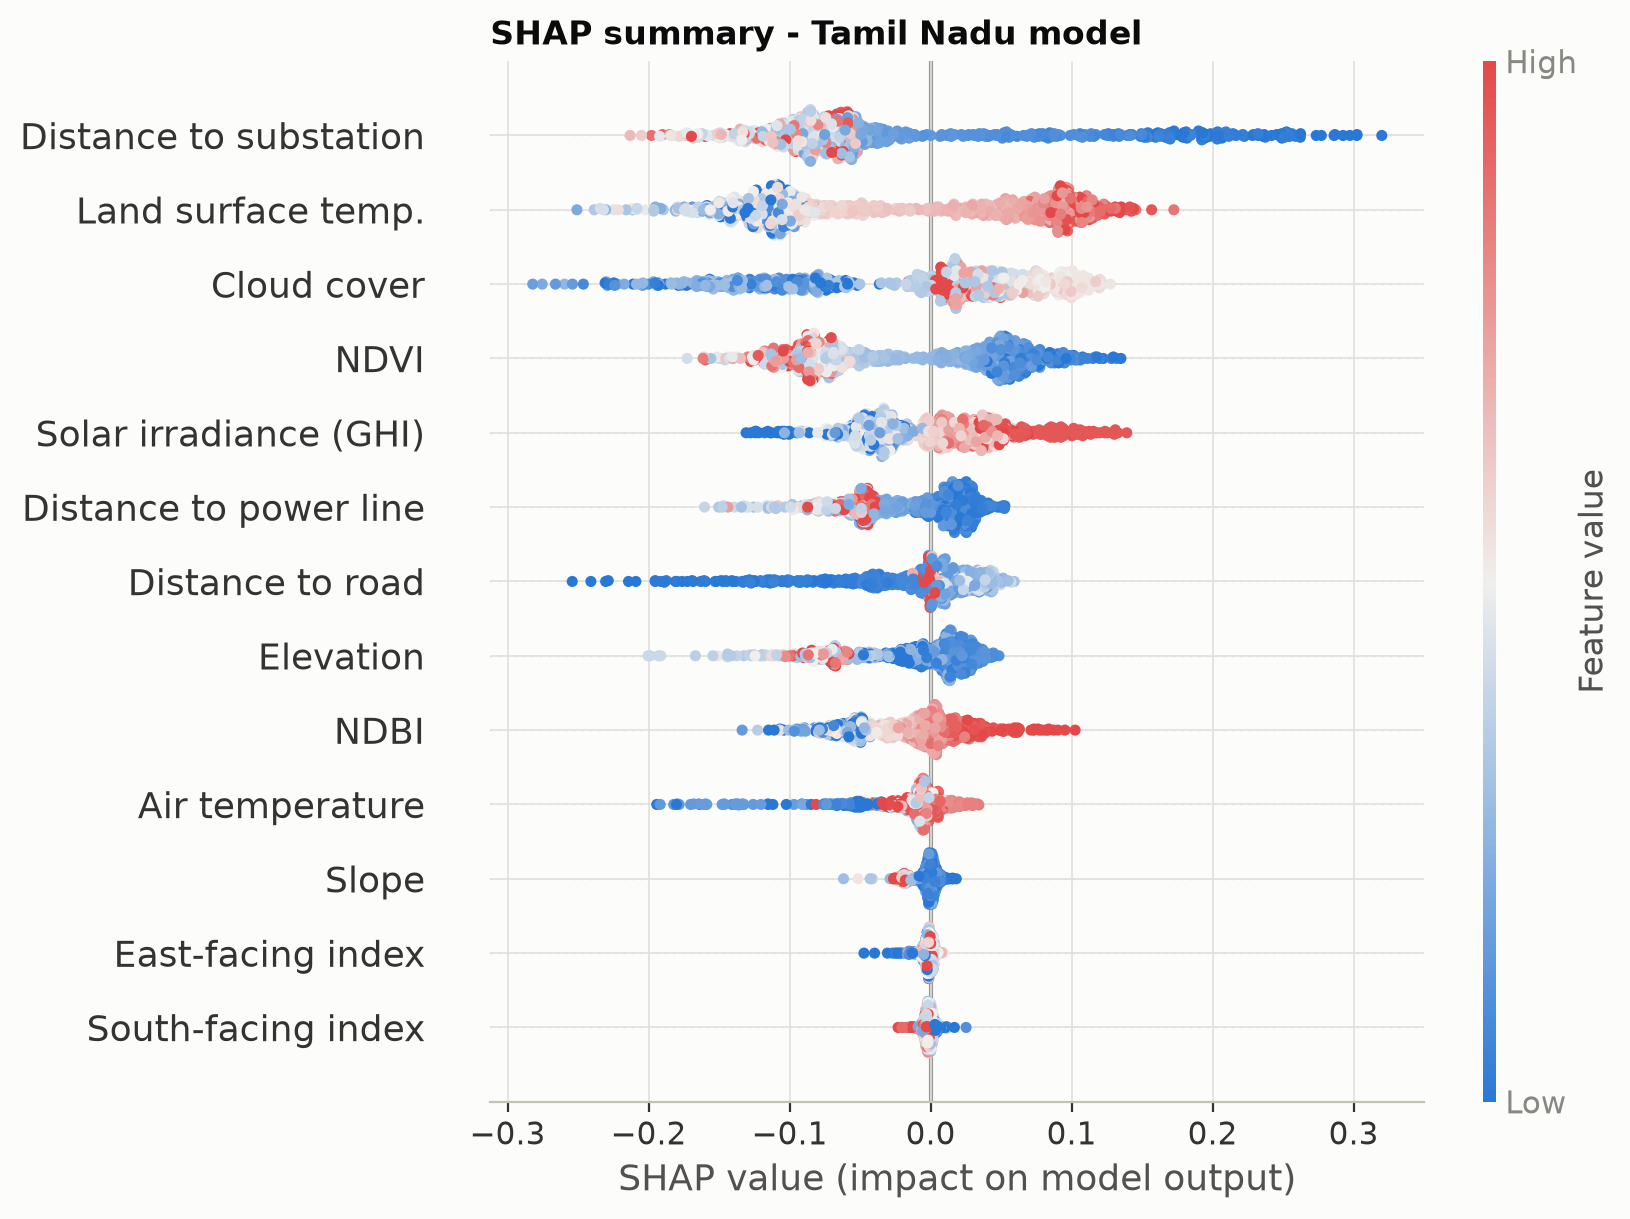

In [7]:
for f in ['feature_importance_global.png', 'shap_summary_global.png',
          'feature_importance_tamil_nadu.png', 'shap_summary_tamil_nadu.png']:
    display(Image(str(config.FIGURES_DIR / f), width=720))

## Per-site prediction, SHAP breakdown and energy estimate

In [8]:
from model.predict import Predictor
p = Predictor(enable_live=False)          # cached grid features - no Earth Engine calls
r = p.predict(9.35, 78.38)                # Kamuthi solar park, Tamil Nadu
print(f"score {r['score']} ({r['class']})  source: {r['provenance']['label']}")
print({k: v['score'] for k, v in r['scores'].items()}, '| TN local:', r.get('tamil_nadu_local', {}).get('score'))
e = r['energy']
print(f"energy: {e['annual_mwh']:.0f} MWh/yr per acre  = {e['area_m2']:.0f} m2 x {e['ghi_kwh_m2_day']:.2f} x 365 x 0.20 x 0.75")
pd.DataFrame(r['shap']['contributions'])[['label', 'value', 'contribution_pct']].head(10).round(3)

score 75.8 (High)  source: Grid estimate (nearest 0.5° cell)
{'ml_siting': 75.8, 'physical': 75.8, 'ahp': 76.7} | TN local: 82.5
energy: 1200 MWh/yr per acre  = 4047 m2 x 5.42 x 365 x 0.20 x 0.75


,label,value,contribution_pct
0,Travel time to city (log),3.584,13.761
1,Air temperature,28.506,-11.095
2,Elevation,30.977,7.994
3,Cloud fraction,68.182,7.725
4,Slope,0.488,7.061
5,Land surface temp.,36.620,5.656
6,NDBI,-0.068,-5.509
7,Population density (log),0.000,-3.912
8,Solar irradiance (GHI),5.416,3.873
9,Night-time lights (log),0.412,2.838


## Global heatmap

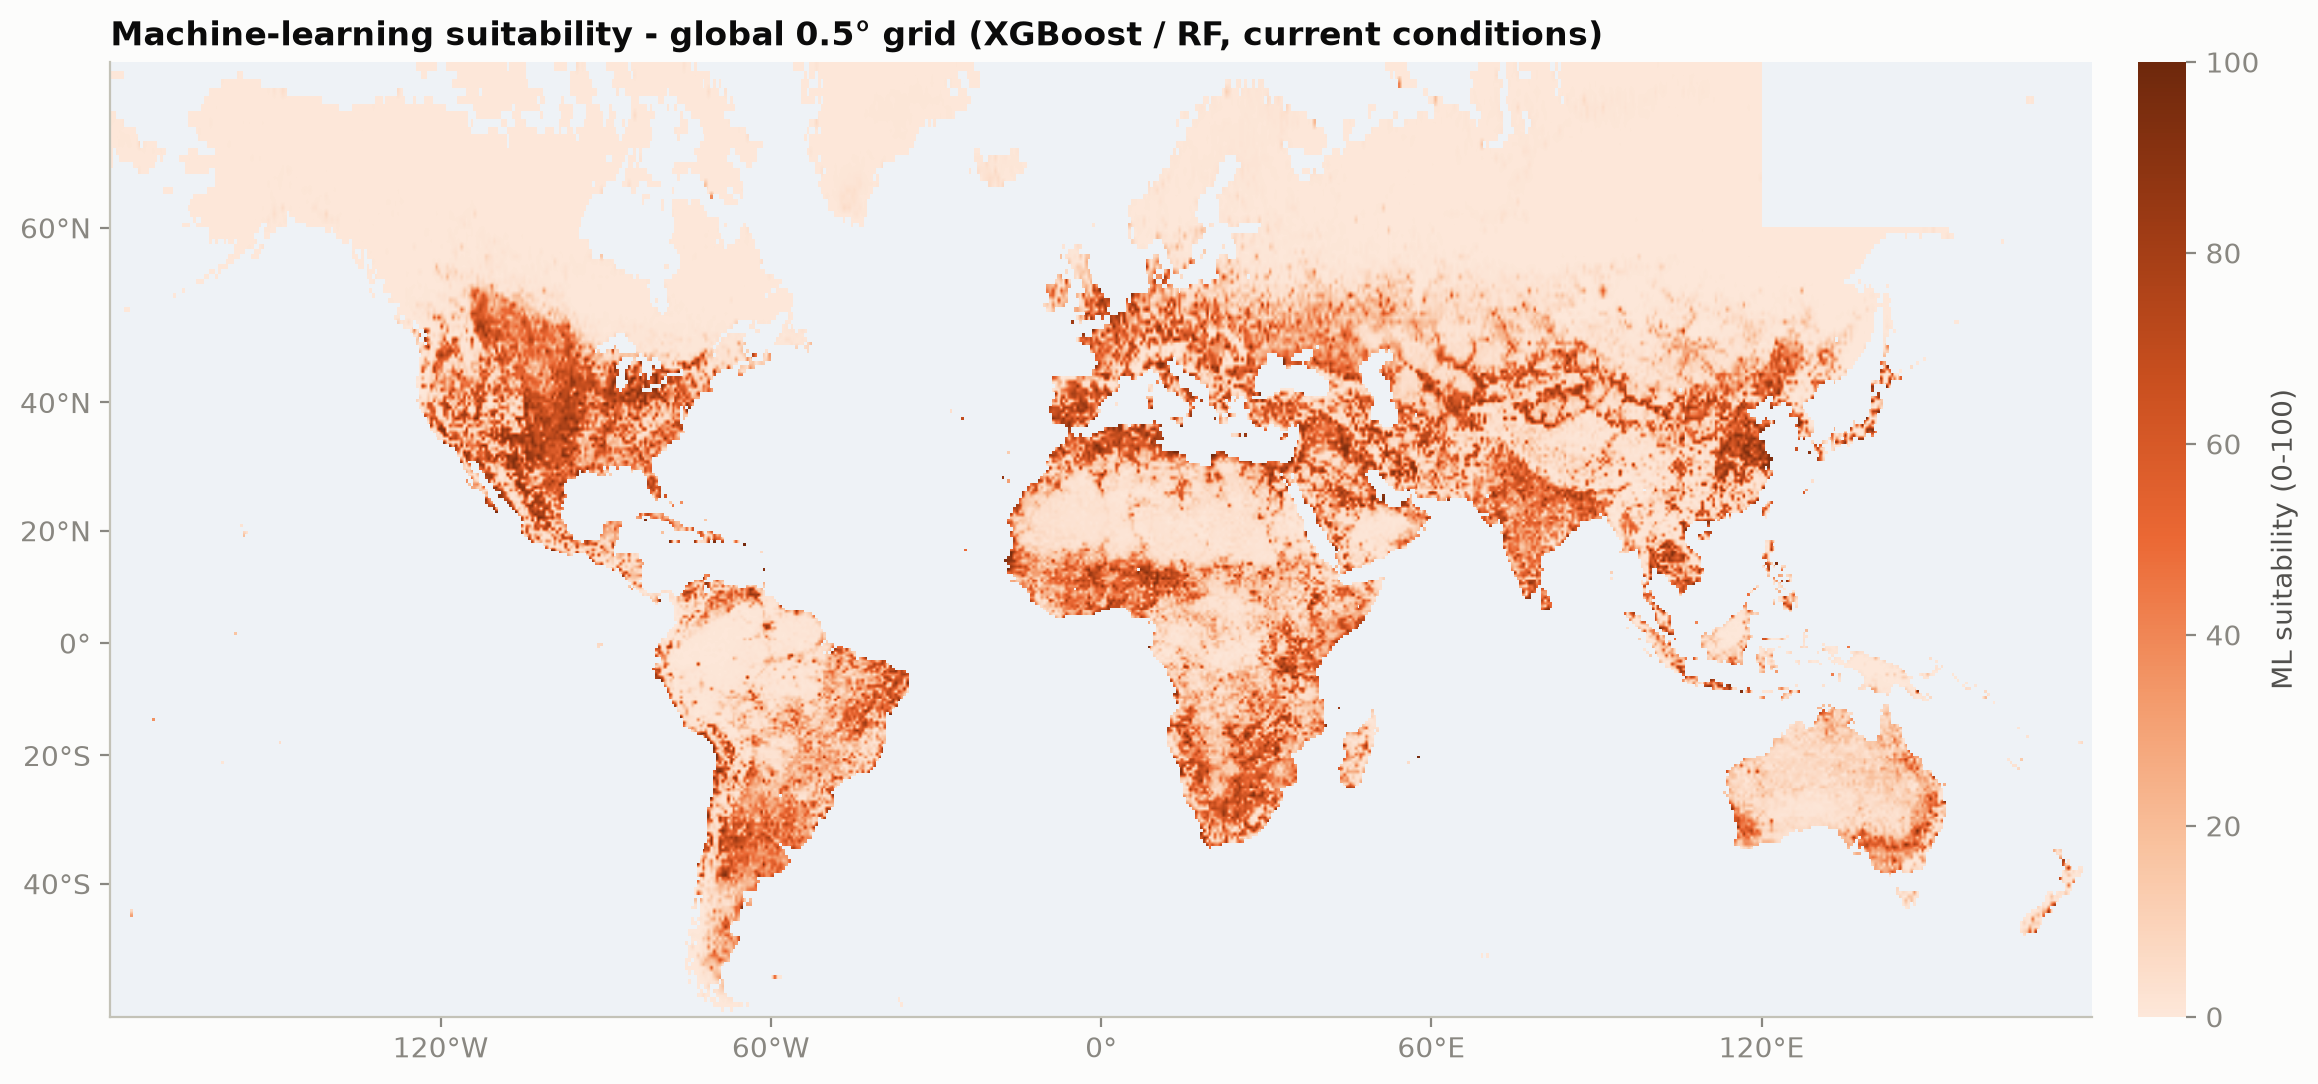

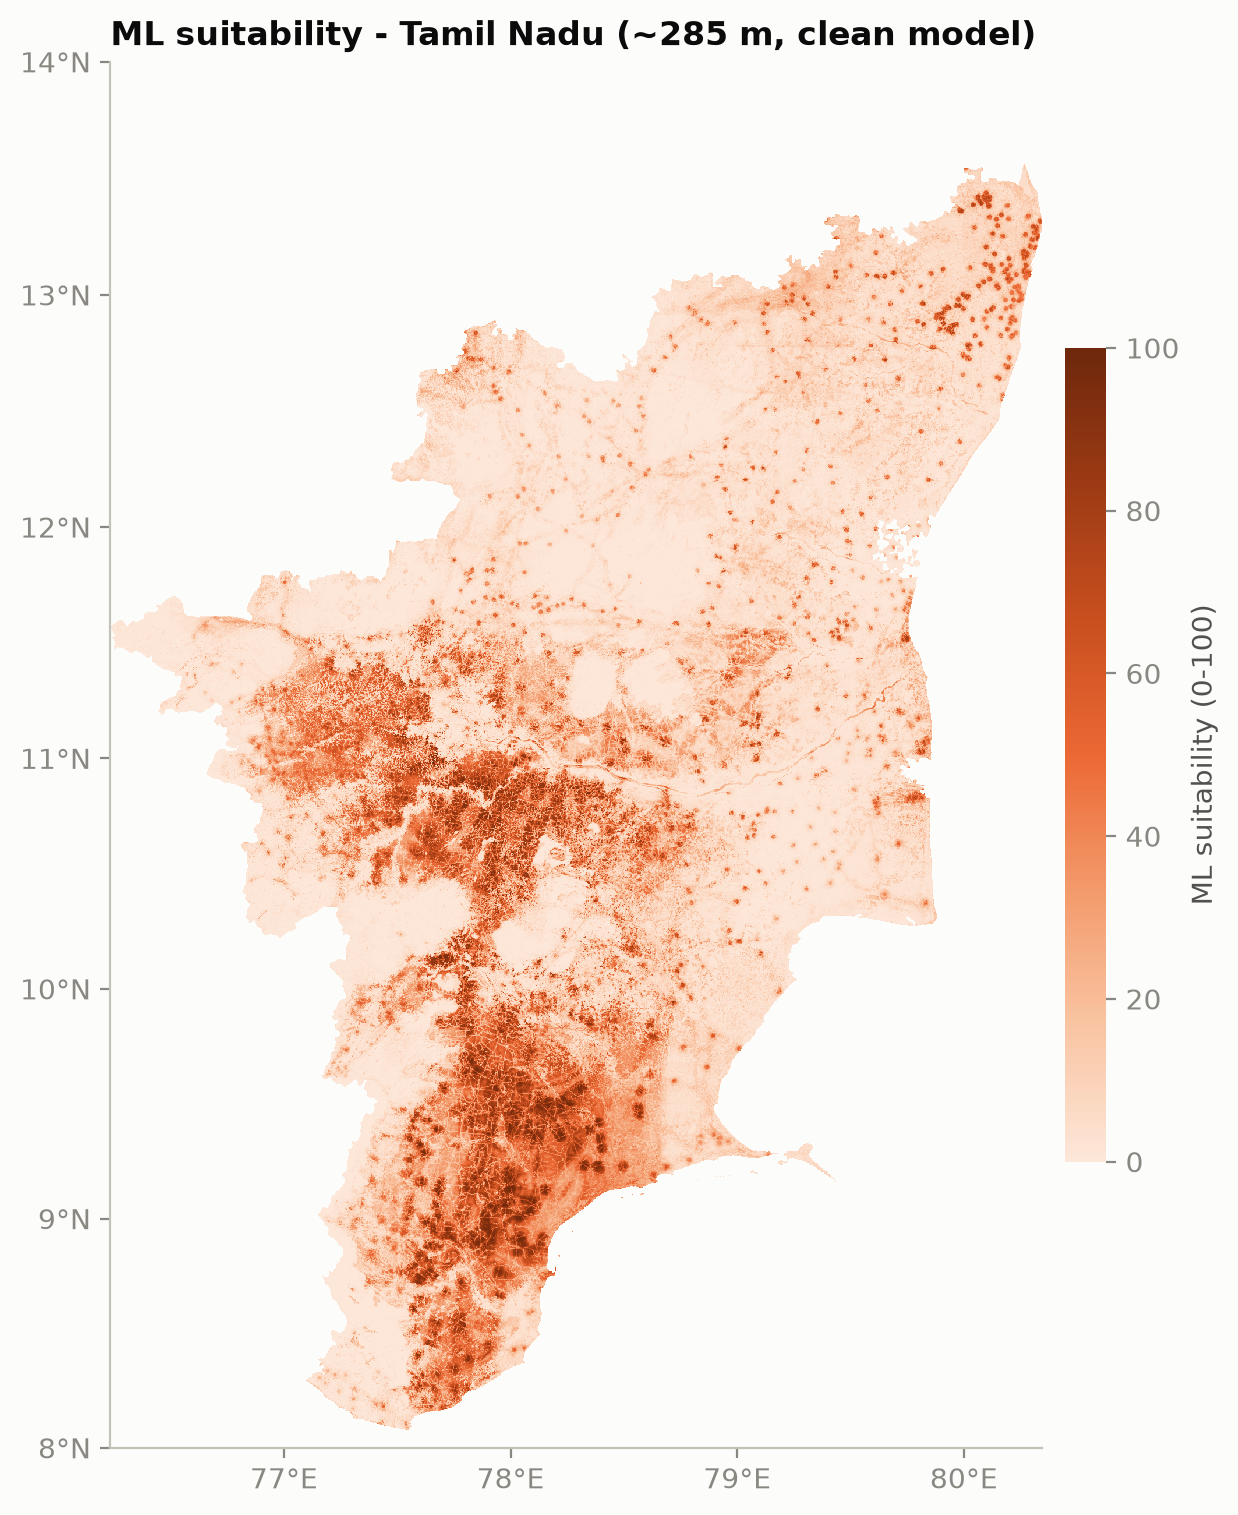

In [9]:
display(Image(str(config.FIGURES_DIR / 'ml_map_global.png'), width=1000))
display(Image(str(config.FIGURES_DIR / 'ml_map_tamil_nadu.png'), width=520))